# Exercise 11-1: Create a multiple regression
Will adding GDP as an indepedent variable improve the predictive power of our model?

## Read the data

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
# Note: The following import is used to avoid warnings related to seaborn
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")


data_dir = "../../data"

In [2]:
awards_df = pd.read_pickle(f"{data_dir}/pkl_files/awards_data_2010_2025.pkl")

In [3]:
# Historical GDP data by quarter
gdp_df = pd.read_csv(f"{data_dir}/GDP_History.csv")

## Prepare the NSF data

In [4]:
# Switch awd_eff_date to datetime
awards_df['awd_eff_date'] = pd.to_datetime(awards_df['awd_eff_date'], format='%Y-%m-%d')

In [5]:
# Add a column that is the first day of the month
awards_df['awd_month_fd'] = awards_df['awd_eff_date'].dt.to_period('M').dt.to_timestamp()
# Add an awd_count column
awards_df['awd_count'] = 1

In [6]:
# Summarize awd_count and awd_amount by awd_month_fd
awards_m_summary_df = awards_df.groupby('awd_month_fd').agg({'awd_count': 'sum', 'awd_amount': 'sum'}).reset_index()

## Prepare the GDP data

In [7]:
# gpd_df has an observation_date column that has the first day of the quarter -- fill in the remaining two months of each quarter, copying in the gdp value
gdp_df['observation_date'] = pd.to_datetime(gdp_df['observation_date'], format='%Y-%m-%d')

# Add two columns that contain the observation date plus 1 month and 2 months
gdp_df['observation_date_plus_1'] = gdp_df['observation_date'] + pd.DateOffset(months=1)
gdp_df['observation_date_plus_2'] = gdp_df['observation_date'] + pd.DateOffset(months=2)
# Melt the three date columns into a single column
# and keep the GDP value
gdp_df = gdp_df.melt(id_vars=['GDP'], value_vars=['observation_date', 'observation_date_plus_1', 'observation_date_plus_2'], var_name='month_offset', value_name='obs_date')
# Keep only the obs_date and GDP columns
gdp_df = gdp_df[['obs_date', 'GDP']]

In [8]:
awards_m_summary_df.head()

,awd_month_fd,awd_count,awd_amount
0,2008-05-01,2,552033.0
1,2008-08-01,1,64257.0
2,2008-09-01,1,113753.0
3,2008-10-01,1,182982.0
4,2008-11-01,1,188160.0


In [9]:
gdp_df.head()

,obs_date,GDP
0,1947-01-01,243.164
1,1947-04-01,245.968
2,1947-07-01,249.585
3,1947-10-01,259.745
4,1948-01-01,265.742


## Combine and tidy up

In [10]:
# Merge awards_m_summary_df with gdp_df
awards_gdp_df = pd.merge(awards_m_summary_df, gdp_df, left_on='awd_month_fd', right_on='obs_date', how='left')

awards_gdp_df.head()

,awd_month_fd,awd_count,awd_amount,obs_date,GDP
0,2008-05-01,2,552033.0,2008-05-01,14865.701
1,2008-08-01,1,64257.0,2008-08-01,14898.999
2,2008-09-01,1,113753.0,2008-09-01,14898.999
3,2008-10-01,1,182982.0,2008-10-01,14608.209
4,2008-11-01,1,188160.0,2008-11-01,14608.209


In [11]:
# Drop the obs_date column
awards_gdp_df.drop(columns=['obs_date'], inplace=True)
# Filter for dates between 2010 and 2024
awards_gdp_df = awards_gdp_df[(awards_gdp_df['awd_month_fd'] >= '2010-01-01') & (awards_gdp_df['awd_month_fd'] <= '2024-12-31')]
# Rename columns
awards_gdp_df.rename(columns={'awd_month_fd': 'awd_month'}, inplace=True)
# Set the index to the awd_month column
awards_gdp_df.set_index('awd_month', inplace=True)


In [24]:
awards_gdp_df.head(20)

,awd_count,awd_amount,GDP
awd_month,,,
2010-01-01,651,8.530975e+08,14764.610
2010-02-01,422,2.066794e+08,14764.610
2010-03-01,706,3.206660e+08,14764.610
2010-04-01,641,3.725661e+08,14980.193
2010-05-01,794,2.416399e+08,14980.193
2010-06-01,1232,4.271483e+08,14980.193
2010-07-01,1666,7.495550e+08,15141.607
2010-08-01,1791,9.023301e+08,15141.607
2010-09-01,3988,2.034628e+09,15141.607


## Identify a correlation

In [12]:
awards_gdp_df.corr()

,awd_count,awd_amount,GDP
awd_count,1.000000,0.881686,-0.007056
awd_amount,0.881686,1.000000,0.007397
GDP,-0.007056,0.007397,1.000000


<Axes: >

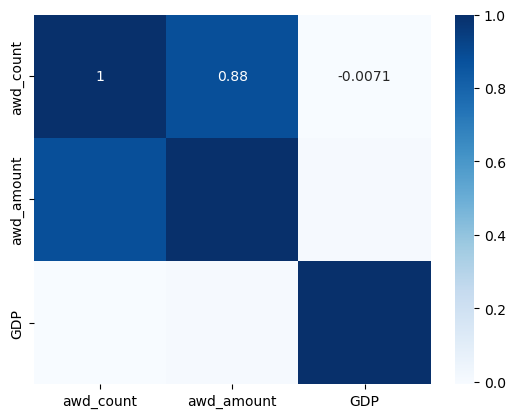

In [13]:
sns.heatmap(data=awards_gdp_df.corr(), annot=True, cmap='Blues')

## Create the multiple regression model

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    awards_gdp_df[['awd_count','GDP']], 
    awards_gdp_df[['awd_amount']])

In [15]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [16]:
model.score(x_test, y_test)

0.5120121657712219

In [17]:
y_predicted = model.predict(x_test)
predicted = pd.DataFrame(y_predicted, columns = ['awd_amount_predicted'])

In [18]:
final = predicted.join([x_test.reset_index(drop=True), 
                       y_test.reset_index(drop=True)])

In [19]:
# Rename awd_amount to awd_amount_actual
final.rename(columns={'awd_amount': 'awd_amount_actual'}, inplace=True)

## Plot the result

In [20]:
# Melt the DataFrame to combine the actual and predicted values into a long format
# The melt() function is used to reshape the DataFrame from wide format to long format.
finalMelt = pd.melt(final, id_vars=['awd_count'], 
                    value_vars=['awd_amount_actual','awd_amount_predicted'], 
                    var_name='Variable', value_name='Value')
finalMelt.head()

,awd_count,Variable,Value
0,763,awd_amount_actual,1.545463e+09
1,496,awd_amount_actual,2.580073e+08
2,417,awd_amount_actual,1.661692e+08
3,182,awd_amount_actual,8.809558e+07
4,2416,awd_amount_actual,1.204002e+09


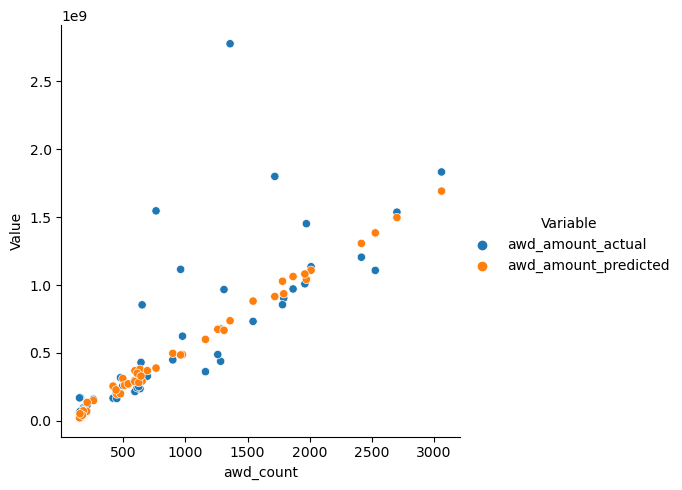

In [21]:
# Make a scatter plot to visualize the relationship between the number of awards and the amount of awards
# in the melted DataFrame, using the Variable column to differentiate between actual and predicted values
# in the legend
sns.relplot(data=finalMelt, x='awd_count', y='Value', hue='Variable')

## Plot the residuals

In [22]:
final['Residual'] = final.awd_amount_actual - final.awd_amount_predicted

<Axes: xlabel='Residual', ylabel='Density'>

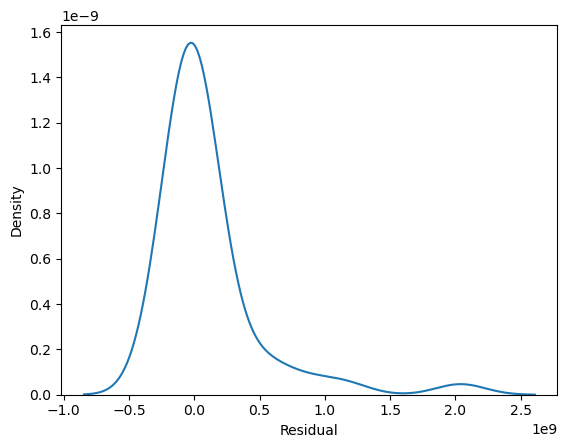

In [23]:
sns.kdeplot(data=final, x='Residual')